In [1]:
from pathlib import Path
import pickle

import numpy as np
from scipy import constants as cst

import matplotlib.pyplot as plt
import tqdm

from centrex_tlf import states, hamiltonian, transitions, couplings, lindblad, utils
from centrex_tlf_julia_extension import lindblad_julia
import cv2
import numpy as np
from scipy.optimize import curve_fit
import scipy.ndimage as ndimage

from PIL import Image

In [2]:
plt.rcParams.update({"font.size": 14})

In [3]:
cwd = Path().cwd()

# Setting up the system

In [4]:
trans = [
    transitions.OpticalTransition(
        transitions.OpticalTransitionType.R, J_ground=2, F1=7 / 2, F=4
    )
]

polarizations = [[couplings.polarization_Z]]

transition_selectors = couplings.generate_transition_selectors(
    trans,
    polarizations,
    ground_mains=[
        1
        * states.CoupledBasisState(
            J=2,
            F=3,
            F1=5 / 2,
            mF=-1,
            I1=1 / 2,
            I2=1 / 2,
            Ω=0,
            P=+1,
            electronic_state=states.ElectronicState.X,
        )
    ],
    excited_mains=[
        1
        * states.CoupledBasisState(
            J=3,
            F=4,
            F1=7 / 2,
            mF=-1,
            I1=1 / 2,
            I2=1 / 2,
            Ω=1,
            P=-1,
            electronic_state=states.ElectronicState.B,
        )
    ],
)

In [5]:
v_to_Γ = utils.detuning.velocity_to_detuning(1)

odepars = lindblad_julia.odeParameters(
    Ω0="rabi_from_intensity(gaussian_2d_rotated(vz*t, y0+vy*t, peak_intensity, laser_center_z, laser_center_y, σz, σy, θ), main_coupling)",
    peak_intensity=1000.0,
    δ0=f"laser_detuning+vx*{v_to_Γ}",  # detuning of the laser [rad/s]
    # laser phase modulation
    ωphase=hamiltonian.Γ,  # laser phase modulation frequency [rad/s]
    β=0,  # laser phase modulation depth [rad]
    PZ0=1,
    # molecules
    z0=0,  # molecule start z position [m]
    vz=184,  # longitudinal molecular velocity [m/s]
    vx=0,
    y0=0.0,
    vy=0.0,
    σz=4.53e-4,
    σy=1.04e-3,
    θ=0,
    laser_detuning = 0,
    laser_center_z=0,
    laser_center_y=0,
    main_coupling=0.5,
)


In [6]:
%%time
obe_system_original = lindblad.setup_OBE_system_transitions(
    trans, transition_selectors, verbose=True, qn_compact=True, decay_channels=None
)

INFO:centrex_tlf.lindblad.utils_setup:generate_OBE_system: 1/5 -> Generating the reduced Hamiltonian
INFO:centrex_tlf.lindblad.utils_setup:generate_OBE_system: 2/5 -> Generating the couplings corresponding to the transitions
INFO:centrex_tlf.lindblad.utils_setup:generate_OBE_system: 3/5 -> Generating the symbolic Hamiltonian
INFO:centrex_tlf.lindblad.utils_setup:generate_OBE_system: 4/5 -> Generating the collapse matrices
INFO:centrex_tlf.lindblad.utils_setup:generate_OBE_system: 5/5 -> Transforming the Hamiltonian and collapse matrices into a symbolic system of equations


CPU times: total: 11.2 s
Wall time: 57.7 s


In [7]:
from copy import deepcopy

obe_system_python = deepcopy(obe_system_original)

In [8]:
obe_system = lindblad_julia.setup_OBE_system_julia(
    obe_system_python, transition_selectors, odepars
)

## Detection Laser Beam Profile

### Read data from thorlabs beam profiler


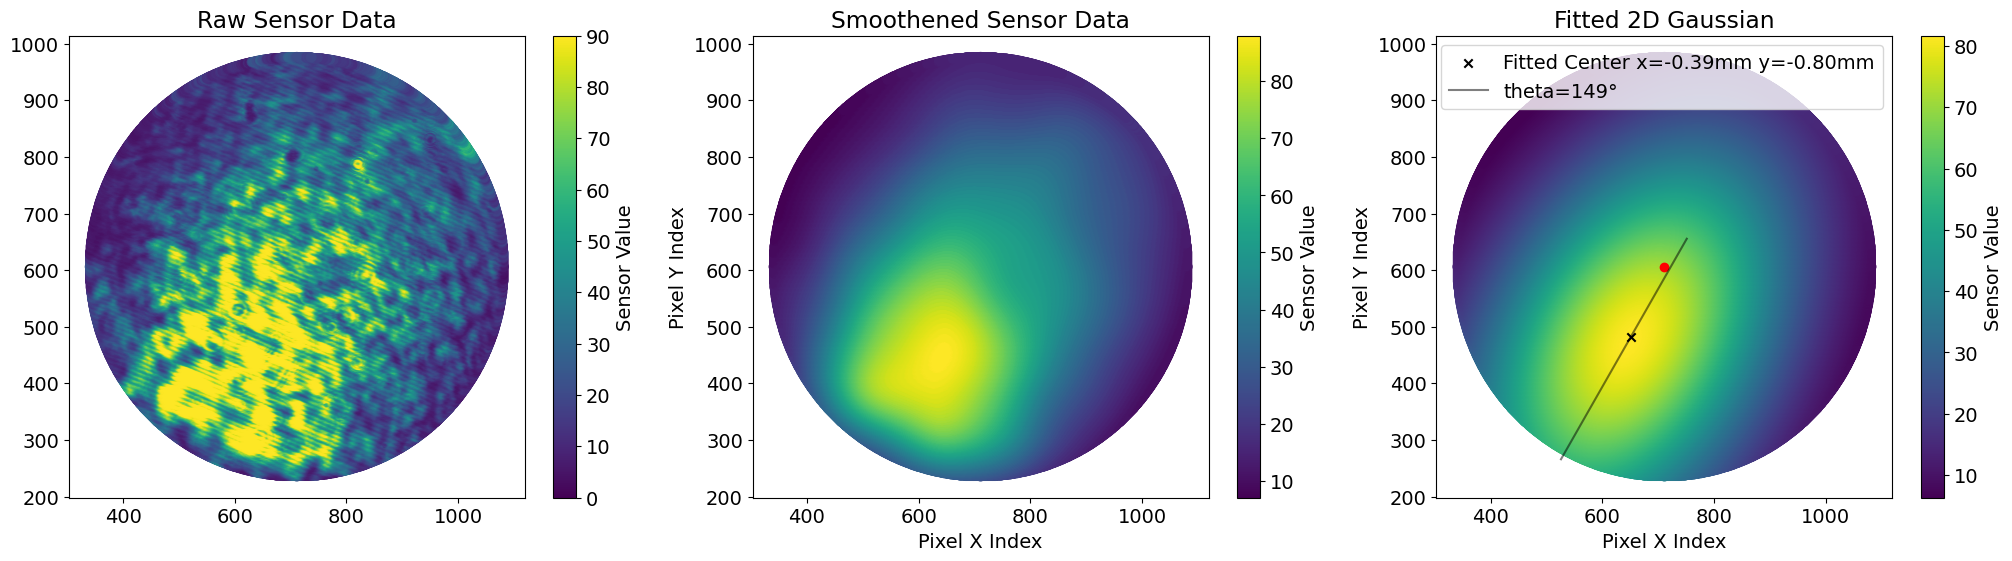

In [9]:

file_path = "beam_profile/DeviceData_#001.png"
# Open the image file
image = Image.open(file_path)

# Convert the image to grayscale (optional, if you need a 2D array)
image = image.convert('L')
# Convert the image to a NumPy array
image_array = np.array(image)
image_array = image_array[::-1, :]
sensor_array = image_array

# Converting the array to uint8 format needed for OpenCV
image = (sensor_array).astype(np.uint8)

# Apply thresholding to create a binary mask of the non-zero data
_, thresholded = cv2.threshold(image, 60, 255, cv2.THRESH_BINARY)

# Find contours of the thresholded image to locate the non-zero areas
contours, _ = cv2.findContours(thresholded, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Combine all contours into one to get a single enclosing circle
all_points = np.vstack(contours)

# Find the minimum enclosing circle that covers all combined contours
(x, y), radius = cv2.minEnclosingCircle(all_points)
center = (int(x), int(y))
radius = int(radius)

# Draw the enclosing circle on the original image
output_image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)  # Convert to BGR for colored circle visualization
cv2.circle(output_image, center, radius, (0, 255, 0), 2)


pixel_x_size, pixel_y_size = 8.77e-3/1360, 6.6e-3/1024

# Define a 2D Gaussian function
def gaussian_2d(xy, amplitude, xo, yo, sigma_x, sigma_y):
    x, y = xy
    xo = float(xo)
    yo = float(yo)
    g = amplitude * np.exp(-(((x - xo) ** 2) / (2 * sigma_x ** 2) + ((y - yo) ** 2) / (2 * sigma_y ** 2)))
    return g.ravel()

# Define the 2D Gaussian function with rotation
def gaussian_2d_rotated(coords, A, x0, y0, sigma_x, sigma_y, theta):
    x, y = coords
    a = np.cos(theta)**2 / (2*sigma_x**2) + np.sin(theta)**2 / (2*sigma_y**2)
    b = np.sin(2*theta) / (2*sigma_x**2) - np.sin(2*theta) / (2*sigma_y**2)
    c = np.sin(theta)**2 / (2*sigma_x**2) + np.cos(theta)**2 / (2*sigma_y**2)

    g = A * np.exp(- a*(x-x0)**2 - b*(x-x0)*(y-y0) - c*(y-y0)**2)
    return g.ravel()

# Initial guess for the Gaussian parameters
initial_guess = (80, 600, 400, 200, 200, 2)  # (A, x0, y0, sigma_x, sigma_y, theta)
# initial_guess = (20, 600, 600, 20, 20)  # (A, x0, y0, sigma_x, sigma_y)

img = ndimage.gaussian_filter(sensor_array, sigma=(50, 50), order=0)

# Generate a grid of x, y coordinates
x = np.arange(img.shape[1])
y = np.arange(img.shape[0])
x, y = np.meshgrid(x, y)

# Create a mask to select data within the circle
mask = (x - center[0])**2 + (y - center[1])**2 <= radius**2

# Apply the mask to extract the relevant data
x_data = x[mask]
y_data = y[mask]
z_data = img[mask]


# Fit the Gaussian model to the data
popt, pcov = curve_fit(gaussian_2d_rotated, (x_data, y_data), z_data, p0=initial_guess, bounds=([-np.inf, -np.inf, -np.inf, -np.inf, -np.inf, 0], [np.inf, np.inf, np.inf, np.inf, np.inf, 2*np.pi]))
# popt, pcov = curve_fit(gaussian_2d, (x_data, y_data), z_data, p0=initial_guess)


# # Extract the fitted parameters
amplitude, xo, yo, sigma_x, sigma_y, theta = popt

# Generate fitted data for visualization
z_fitted = gaussian_2d_rotated((x, y), *popt).reshape(sensor_array.shape)


# Plot fitted Gaussian
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(25, 6))
scatter1 = ax1.scatter(x_data, y_data, c=sensor_array[mask], vmin=0, vmax=90, cmap='viridis')
ax1.set_title('Raw Sensor Data')
ax2.set_xlabel('Pixel X Index')
ax2.set_ylabel('Pixel Y Index')
fig.colorbar(scatter1, ax=ax1, label='Sensor Value')

scatter2 = ax2.scatter(x_data, y_data, c=z_data, cmap='viridis')
ax2.set_title('Smoothened Sensor Data')
ax2.set_xlabel('Pixel X Index')
ax2.set_ylabel('Pixel Y Index')
fig.colorbar(scatter2, ax=ax2, label='Sensor Value')

scatter3 = ax3.scatter(x_data, y_data, c=z_fitted[mask], cmap='viridis')
ax3.set_title('Fitted 2D Gaussian')
ax3.set_xlabel('Pixel X Index')
ax3.set_ylabel('Pixel Y Index')     
ax3.scatter(center[0], center[1], color='red', marker='o') 
ax3.scatter(popt[1], popt[2], color='black', marker='x', label=f'Fitted Center x={(xo-center[0])*pixel_x_size*1e3:.2f}mm y={(yo-center[1])*pixel_y_size*1e3:.2f}mm') 
ax3.plot(popt[1]+np.arange(-250,250,50)*np.sin(theta), popt[2]-np.arange(-250,250,50)*np.cos(theta), color='black', alpha=0.5, label=f'theta={int(theta*180/np.pi)}°')
fig.colorbar(scatter3, ax=ax3, label='Sensor Value')
ax3.legend()


In [10]:
popt

array([ 81.67679746, 650.90389165, 482.29066023, 175.13484966,
       278.34156413,   2.61745449])

In [11]:
(yo-center[1])*pixel_y_size

-0.0007973453540083156

In [12]:
sigma_x*pixel_x_size, sigma_y*pixel_y_size

(0.0011293622290713518, 0.0017939983625552612)

# Scan Frequency for Various Trajectories

In [13]:
def get_diagonal_indices_flattened(size, states=None, mode="python"):
    if states is None:
        indices = [i + size * i for i in range(size)]
    else:
        indices = [i + size * i for i in states]
    if mode == "julia":
        return [i + 1 for i in indices]
    elif mode == "python":
        return indices
state_selector = states.QuantumSelector(electronic=states.ElectronicState.B)
indices = state_selector.get_indices(obe_system.QN)
save_idxs = get_diagonal_indices_flattened(len(obe_system.QN), indices, mode="julia")

## Run simulation

In [45]:
from rich import progress



ρ = utils.population.generate_uniform_population_states(
    states.QuantumSelector(J=2, F=3, electronic=states.ElectronicState.X), obe_system.QN
)

odepars.σz, odepars.σy = sigma_x*pixel_x_size, sigma_y*pixel_y_size
odepars.β = 0
odepars.θ = theta
odepars.laser_center_z, odepars.laser_center_y = -(xo-center[0])*pixel_x_size, (yo-center[1])*pixel_y_size
power = 0.03


peak_intensity = power / (2 * np.pi * odepars.σz * odepars.σy)

odepars.peak_intensity = peak_intensity

ensemble_config = lindblad_julia.OBEEnsembleProblemConfig(
    method="Tsit5()",
    save_idxs=save_idxs,
    saveat=1e-6,
    abstol=1e-10,
    reltol=1e-7,
)

problem = lindblad_julia.OBEProblem(odepars, ρ, tspan=(0, 50e-6))
frequencies = np.arange(-10, 10, 0.1) * 2 * np.pi * 1e6 * 4 

scan_values = [frequencies]
parameters = ["laser_detuning"]

output_func = lindblad_julia.setup_state_integral_calculation_state_idxs(
    nphotons=True
)

ensemble_problem = lindblad_julia.OBEEnsembleProblem(
    problem=problem,
    parameters=parameters,
    scan_values=scan_values,
    output_func=output_func,
    zipped=True,
)

lindblad_julia.setup_problem_parameter_scan(ensemble_problem)

lindblad_julia.solve_problem_parameter_scan(ensemble_problem, ensemble_config)

results = lindblad_julia.get_results_parameter_scan(ensemble_problem)

# with open("results_scan_freq.pkl", "wb") as f:
#     pickle.dump(results_scan, f)

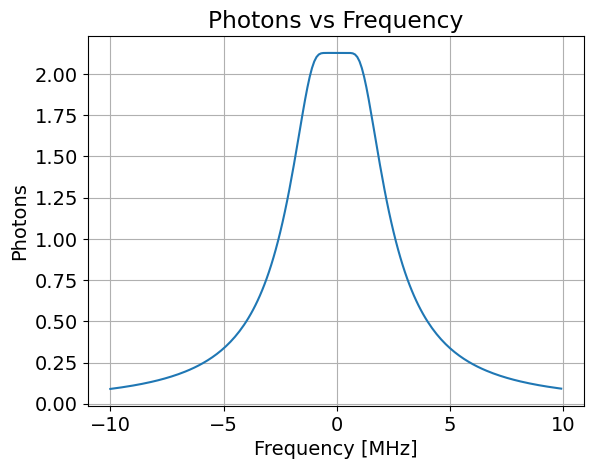

In [46]:
plt.plot(frequencies / (2 * np.pi * 1e6 * 4), results.results)
plt.xlabel("Frequency [MHz]")
plt.ylabel("Photons")
plt.title("Photons vs Frequency")
plt.grid(True)

In [60]:
with open("results_scan_freq.pkl", "rb") as f:
    results_scan = pickle.load(f)

## Gain vs Voltage

In [75]:
pop_mapping

{'mF=0': 3, 'mF=2': 2, 'mF=3': 2}

In [78]:
print(obe_system.preamble)

function Lindblad_rhs!(du, ρ, p, t)
    	@inbounds begin
    		peak_intensity = p[1]
		ωphase = p[2]
		β = p[3]
		PZ0 = p[4]
		z0 = p[5]
		vz = p[6]
		vx = p[7]
		y0 = p[8]
		vy = p[9]
		σz = p[10]
		σy = p[11]
		θ = p[12]
		laser_detuning = p[13]
		laser_center_z = p[14]
		laser_center_y = p[15]
		main_coupling = p[16]
		Ω0 = rabi_from_intensity(gaussian_2d_rotated(vz*t, y0+vy*t, peak_intensity, laser_center_z, laser_center_y, σz, σy, θ), main_coupling)
		δ0 = laser_detuning+vx*23054294.945029873
		Ω0ᶜ = conj(Ω0)



In [76]:
obe_system.code_lines

['du[1,2] = 0.100555419921875*1im*ρ[1,2]',
 'du[1,3] = 0.20068359375*1im*ρ[1,3]',
 'du[1,4] = 279720.373291016*1im*ρ[1,4]',
 'du[1,5] = 279720.331634521*1im*ρ[1,5]',
 'du[1,6] = 279720.289367676*1im*ρ[1,6]',
 'du[1,7] = 279720.24810791*1im*ρ[1,7]',
 'du[1,8] = 279720.206207275*1im*ρ[1,8]',
 'du[1,9] = 2031549.61428833*1im*ρ[1,9]',
 'du[1,10] = 2031549.61993408*1im*ρ[1,10]',
 'du[1,11] = 2031549.62585449*1im*ρ[1,11]',
 'du[1,12] = 2031549.63153076*1im*ρ[1,12]',
 'du[1,13] = 2031549.6385498*1im*ρ[1,13]',
 'du[1,14] = -1.0*1im*(-0.341564966981031*PZ0*Ω0ᶜ*ρ[1,23] - ρ[1,14]*(1.0*δ0 + 0.13726806640625) - 251619072761.693*ρ[1,14])',
 'du[1,15] = -1.0*1im*(-0.447213568243895*PZ0*Ω0ᶜ*ρ[1,24] - ρ[1,15]*(1.0*δ0 + 0.06884765625) - 251619072761.693*ρ[1,15])',
 'du[1,16] = -1.0*1im*(-0.5*PZ0*Ω0ᶜ*ρ[1,25] - 1.0*δ0*ρ[1,16] - 251619072761.693*ρ[1,16])',
 'du[1,17] = -1.0*1im*(-0.516395274536588*PZ0*Ω0ᶜ*ρ[1,26] - 0.0015438692186427*PZ0*Ω0ᶜ*ρ[1,27] - ρ[1,17]*(1.0*δ0 - 0.0684814453125) - 251619072761.693*ρ

C:\Users\zhoup\AppData\Local\Temp\ipykernel_79136\513987979.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


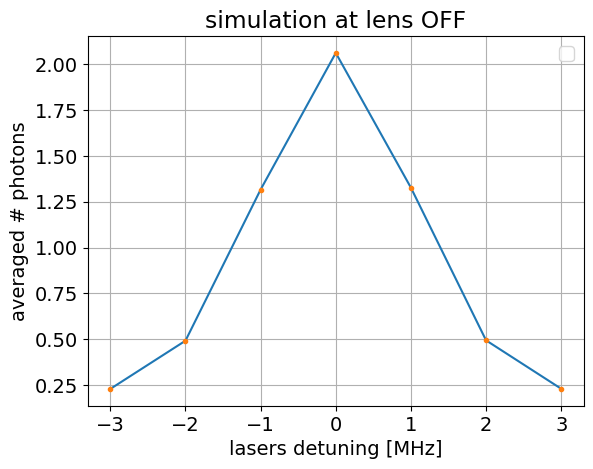

In [80]:
def division_error_propagation(a,sa,b,sb):
    return a/b * np.sqrt((sa/a)**2+(sb/b)**2)

fig, ax = plt.subplots()

signal = []
frequencies = []
signal_err = []
for f, res in results_scan.items():
    frequencies.append(f)
    for mF in res[0].keys():
        if res[0][mF] is None:
            break
        if len(frequencies) == 0:
            frequencies.append(f)
        if frequencies[-1] != f:
            frequencies.append(f)

        signal.append(res[0][mF].results.mean() * pop_mapping[mF] / 7)
        signal_err.append(0)#np.sqrt(res[30000][mF].results.sum()) * pop_mapping[mF] / 7)
frequencies = np.array(frequencies)
signal = np.array(signal).reshape(-1, 3).sum(axis=1)
signal_err_reshaped = np.array(signal_err).reshape(-1, 3)
# Sum along the mFs
signal_err_summed = signal_err_reshaped.sum(axis=1)
signal_err_summed = division_error_propagation(signal, signal_err_summed, signal[0], signal_err_summed[0])


ax.plot(frequencies, signal)

ax.plot(frequencies, signal, ".")
ax.set_title('simulation at lens OFF')
ax.set_xlabel("lasers detuning [MHz]")
ax.set_ylabel("averaged # photons")
ax.legend()
ax.grid()


In [81]:
signal.sum()

6.1478774300953365

In [ ]:
signal

array([ 5658.99395903,  5699.46658083,  6126.06923064,  7446.22805539,
       10668.98664355, 18843.91103219, 31844.35588037])

In [ ]:
signal_err_summed

array([0.04976664, 0.05003429, 0.05282587, 0.0613641 , 0.0817018 ,
       0.13205254, 0.21175621])

In [ ]:
signal / signal[0]

array([1.        , 1.00715191, 1.0825368 , 1.31582188, 1.88531508,
       3.32990478, 5.6272115 ])

In [ ]:
fwhm = 2 * np.sqrt(2 * np.log(2)) * odepars.σz
waist = np.sqrt(2) * fwhm / (2 * np.sqrt(np.log(2)))

peak_intensity = 2 * power / (np.pi * waist**2)

peak_intensity


2292.0106971280175